<h1> Configuramos LangChain con Groq (modelo gratuito) </h1>

In [ ]:
# La integración de Groq con LangChain y LangGraph
!pip install -U langchain-groq langchain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.4/106.4 kB 2.7 MB/s eta 0:00:00
  Attempting uninstall: langchain
    Found existing installation: langchain 1.2.2
    Uninstalling langchain-1.2.2:
      Successfully uninstalled langchain-1.2.2


In [ ]:
from langchain_groq import ChatGroq
from google.colab import userdata

GROQ_API_KEY = userdata.get('GROQ_API_KEY')

print("Api key de Groq cargada")

# El modelo que usarán todos los agentes (Groq)
model = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=GROQ_API_KEY
)

print("Modelo de Groq cargado")

Api key de Groq cargada
Modelo de Groq cargado


In [ ]:
!pip install langgraph
!pip install wikipedia

<h1>Creamos State donde se guardará la información usada por los nodos</h1>

In [ ]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from typing_extensions import TypedDict, Annotated
from pydantic import BaseModel, Field

# En esta clase se van guardando la información
# que irán usando los distintos nodos de LangGraph
class State(TypedDict):
  query: str
  model_calls: int
  research_info: str
  is_info_relevant: bool
  improved_query: str
  email: str
  research_attempts: int

<h1>Consulta a Wikipedia </h1>

In [ ]:
import wikipedia
wikipedia.set_lang("es")

def search_in_wikipedia(query: str, isMovie: bool = False):
    if isMovie:
        query += " (film)"
    try:
        summary = wikipedia.summary(query, sentences=15)
        page = wikipedia.page(query)
        content = page.content[:5000]  # contenido
        return f"{summary}\n\n{content}\n\nFuente: {page.url}"
    except wikipedia.exceptions.DisambiguationError as e:
        # Tomar varias opciones si hay ambigüedad
        results = []
        for option in e.options[:5]:
            try:
                results.append(wikipedia.summary(option, sentences=10))
            except:
                continue
        return "Consulta ambigua. Posibles resultados:\n" + "\n".join(results)
    except Exception:
        return "No se encontró información en Wikipedia."


In [ ]:
from langchain.tools import tool

@tool
def wikipedia_search(query: str, isMovie: bool = False) -> str:
    """
    Busca información verídica en Wikipedia en español.
    """
    return search_in_wikipedia(query, isMovie)


In [ ]:
!pip install langchain_community
!pip install ddgs

In [ ]:
# ===============================
# DuckDuckGo Tool
# ===============================
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import Tool

search_tool = Tool(
    name="search",
    func=DuckDuckGoSearchRun().run,
    description="Buscar noticias recientes de cine en Internet"
)

In [ ]:
import requests

def get_tmdb_top_movies(year, api_key, n=20):
    url = f"https://api.themoviedb.org/3/discover/movie"
    params = {
        "api_key": api_key,
        "language": "es-ES",
        "sort_by": "revenue.desc",
        "primary_release_year": year,
        "page": 1
    }
    response = requests.get(url, params=params)
    data = response.json().get("results", [])
    return data[:n]

<h2>Generar poster con IA para el correo</h2>
Para dar más riqueza a los correos que enviemos , generaremos una imagen con un modelo de huggin face: (se ha añadido en un cuaderno aparte debido a los tiempos de carga)

<h1>Creamos los nodos de LangGraph</h1>
<p>Los nodos ejecutarán las llamadas al modelo, cada nodo tiene una función específica distinta. En nuestro caso estos nodos:</p>

<ul><li>Researcher: busca información en internet a partir de la consulta del usuario.</li>
<li>Evaluator: comprueba que la información obtenida es válida, verídica y suficiente. Enruta el workflow, si acepta el resultado, lo envía al siguiente nodo y si no, vuelve a llamar al nodo de búsqueda.</li>
<li>Writer: con la información, construye un correo electrónico para enviar al usuario.</li>
</ul>

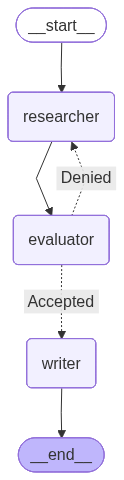

Usando DuckDuckGo
is_info_relevant=True improved_query='Las películas más taquilleras de 2025'
<html>
  <head>
    <title>Novedades del cine en 2025</title>
    <style>
      body {
        font-family: Arial, sans-serif;
        background-color: #f0f0f0;
      }
      
      h1 {
        color: #333;
        font-size: 24px;
        margin-bottom: 10px;
      }
      
      p {
        margin-bottom: 20px;
      }
      
      table {
        border-collapse: collapse;
        width: 100%;
      }
      
      th, td {
        border: 1px solid #ddd;
        padding: 10px;
        text-align: left;
      }
      
      th {
        background-color: #f0f0f0;
      }
    </style>
  </head>
  <body>
    <h1>Resumen de películas taquilleras en 2025</h1>
    <p>¡Hola a todos! ¿Ya saben qué películas más taquilleras se estrenaron en 2025? En este correo electrónico les presentamos las más destacadas, con datos interesantes y una visión general del cine en este año.</p>
    
    <h2>¿Qué p

In [ ]:
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import ChatPromptTemplate

# -- Nodo que busca información --
def researcher(state: State):
    attempts = state.get("research_attempts", 0) + 1
    query = state.get("improved_query", state["query"])

    keywords = ["resumen", "noticias", "actual", "últimos"]
    use_web = any(k in query.lower() for k in keywords)

    all_info = []

    if use_web:
        print("Usando DuckDuckGo")
        for subquery in [query, query + " noticias", query + " taquillas"]:
            info = DuckDuckGoSearchRun().run(subquery)
            all_info.append(info)
    else:
        print("Usando Wikipedia")
        is_movie = any(k in query.lower() for k in ["película", "film", "cine"])
        all_info.append(wikipedia_search(query=query, isMovie=is_movie))

    combined_info = "\n\n".join(all_info)

    return {
        "research_info": combined_info,
        "research_attempts": attempts,
        "model_calls": state.get("model_calls", 0) + 1
    }

# -- Nodo que evalúa si se puede completar el email con la información obtenida --
class Feedback(BaseModel):
    is_info_relevant: bool = Field(description="Si la información obtenida es suficiente para responder la pregunta, el valor es True, si no es suficiente, es False")
    improved_query: str = Field(description="Consulta que responderá la pregunta correctamente")

evaluator_model = model.with_structured_output(Feedback)

def evaluator(state: State):
    feedback = evaluator_model.invoke(
        f"Verifica si la información obtenida: {state['research_info']} es suficiente para responder esta pregunta del usuario verídicamente {state['query']}"
    )
    print(feedback)
    return {
        "is_info_relevant": feedback.is_info_relevant,
        "improved_query": feedback.improved_query,
        "model_calls": state.get('model_calls', 0) + 1
    }

def router(state: State):
    if state['is_info_relevant'] or state['research_attempts'] >= 3:
        return "Accepted"
    else:
        return "Denied"

# -- Nodo que escribe el contenido del email --
def writer(state: State):
    """Crea un email tipo newsletter"""
    prompt = f"""
Sabiendo que la consulta del usuario es: {state['query']},
y la información que hemos recolectado es: {state['research_info']},

Crea un código HTML completo para un correo electrónico tipo newsletter, incluyendo:
- Una introduccion divertida sobre lo que se te pregunte en el prompt
- Secciones con títulos claros
- Resumen detallado de las películas
- Curiosidades y datos de taquilla
- Actores principales
- Críticas relevantes
- Tablas organizadas por posición, título y recaudación
- Formato visual bonito y coherente, con <html>, <body>, <h1>, <p>, <table>, <tr>, <td>, etc.
- Y finalmente cierra con alguna conclusion, sin nombres
"""

    msg = model.invoke(prompt)

    import re
    html_only_match = re.search(r"<html.*?>.*?</html>", msg.content, flags=re.DOTALL)
    if html_only_match:
        email_html = html_only_match.group(0)
    else:
        email_html = msg.content  # fallback

    return {
        "email": email_html,
        "model_calls": state.get('model_calls', 0) + 1
    }

# Construimos el workflow
movie_email_builder = StateGraph(State)
movie_email_builder.add_node("researcher", researcher)
movie_email_builder.add_node("evaluator", evaluator)
movie_email_builder.add_node("writer", writer)
movie_email_builder.add_edge(START, "researcher")
movie_email_builder.add_edge("researcher", "evaluator")
movie_email_builder.add_conditional_edges("evaluator", router, {"Accepted": "writer", "Denied": "researcher"})
movie_email_builder.add_edge("writer", END)

# Visualizamos el workflow
movie_email_workflow = movie_email_builder.compile()
display(Image(movie_email_workflow.get_graph().draw_mermaid_png()))

msg = movie_email_workflow.invoke({"query": "Resumen de películas taquilleras en 2025"})
print(msg['email'])


In [ ]:
import os
import requests
import base64
from google.colab import userdata

RESEND_API_KEY = userdata.get("MAIL_API_KEY")

to_email = "spamphp123456@gmail.com"
from_email = "onboarding@resend.dev"
subject = "Newsletter de películas"

# HTML generado por LangGraph
html_body = msg["email"]

# Codificamos la imagen para enviarla como adjunto
with open("poster.webp", "rb") as f:
    poster_data = base64.b64encode(f.read()).decode()

# Payload para la API de Resend incluyendo únicamente el adjunto
payload = {
    "from": from_email,
    "to": [to_email],
    "subject": subject,
    "html": html_body,
    "attachments": [
        {
            "filename": "poster.webp",
            "type": "image/webp",
            "content": poster_data
        }
    ]
}

# Enviamos el email
response = requests.post(
    "https://api.resend.com/emails",
    json=payload,
    headers={
        "Authorization": f"Bearer {RESEND_API_KEY}",
        "Content-Type": "application/json"
    }
)

#Comprobar que se ha enviado
if response.status_code in [200, 201]:
    print("Email enviado correctamente")
else:
    print("Error al enviar email:", response.status_code, response.text)


Email enviado correctamente
